In [1]:
import numpy as np
import matplotlib.pyplot as plt

from TidalPy import version
print("TidalPy version:", version)
from TidalPy.RadialSolver import radial_solver
from TidalPy.constants import radius_jupiter, mass_jupiter, mass_solar
from TidalPy.tides.modes.multilayer_modes import collapse_multilayer_modes as calculate_tidal_heating

from helpers import build_rs_inputs, rs_optional_args, cmm_optional_args
from structures import CoreLayer, MantleLayer, GasLayer, Planet

TidalPy version: 0.6.8


## Hat-P-26 b

In [16]:
class Hat_P_26b(Planet):

    calculate_called = False

    def __init__(self):

        self.name = "HAT-P-26 b"
        # Values from Stassun et al. 2017 unless otherwise noted
        # https://iopscience.iop.org/article/10.3847/1538-3881/aa5df3/pdf
        self.radius = 0.63 * radius_jupiter
        self.host_mass = 0.816 * mass_solar # From Hartman https://iopscience.iop.org/article/10.1088/0004-637X/728/2/138/pdf
        self.orbital_period = 4.23452
        self.eccentricity = 0.12
        self.obliquity = np.radians(0.0) # Assume 0 for now.
        self.spin_period = self.orbital_period # Assume tidally locked for now.

        # Build Layer Structure
        # Values and structure are total guess for demo purposes.
        core = CoreLayer(
            radius = 0.05 * self.radius,
            name = "Core",
            density = 12000.0,
            shear_modulus = 300.0e9,
            bulk_modulus = 1500.0e9,
            shear_viscosity = 1.0e30
        )
        mantle = MantleLayer(
            radius = 0.2 * self.radius,
            name = "Mantle",
            density = 6000.0,
            shear_modulus = 100.0e9,
            bulk_modulus = 500.0e9,
            shear_viscosity = 1.0e24
        )
        lower_atmo = GasLayer(
            radius = 0.6 * self.radius,
            name = "Lower Atmo",
            density = 1100.0,
            shear_modulus = 0.0,
            bulk_modulus = 10.0e9,
            shear_viscosity = 1000.0
        )
        upper_atmo = GasLayer(
            radius = self.radius,
            name = "Upper Atmo",
            density = 200.0,
            shear_modulus = 0.0,
            bulk_modulus = 10.0e9,
            shear_viscosity = 1000.0
        )
        
        self.layers = [
            core,
            mantle,
            lower_atmo,
            upper_atmo
        ]
    
    def calculate(self):
        
        rs_inputs, cmm_inputs, other_arrays = build_rs_inputs(self)
        self.rs_solution = radial_solver(*rs_inputs, **rs_optional_args)

        self.rs_inputs = rs_inputs
        self.other_arrays = other_arrays

        print("Performing Tidal Heating Calculating; this can take a minute")
        self.tidal_heating_output = calculate_tidal_heating(*cmm_inputs, **cmm_optional_args)
        self.tidal_heating = self.tidal_heating_output[0]
        self.total_tidal_heating = np.nansum(self.tidal_heating)
        # Find complex k2 from y_5 at the surface
        self.k2 = (np.real(self.tidal_heating_output[7][4][-1]) - 1.0) + 1.0j * np.imag(self.tidal_heating_output[7][4][-1])
        self.effective_Q = np.abs(self.k2) / -np.imag(self.k2)
        print("Done with calculations!")
        print()
        print(f"Structure Details for {self.name}:")
        print(f"\tBulk Density  = {rs_inputs.planet_bulk_density/1000:0.2f} "
        print(f"Tidal Heating Findings for {self.name}:")
        print(f"\tTotal Heating = {self.total_tidal_heating/1e9:0.3e} GW.")
        print(f"\t              = {self.total_tidal_heating/1e12:0.3e} TW.")
        print(f"\tRe[k2]        = {np.real(self.k2):0.4f}.")
        print(f"\tEffective Q   = {self.effective_Q:0.3e}.")
        
        self.calculate_called = True

    def plot(self):
        from graphics import tidal_heating_layers_plot
        if not self.calculate:
            raise RuntimeError
        
        self.rs_solution.plot_interior()
        self.rs_solution.plot_ys()
        tidal_heating_layers_plot(self, self.other_arrays, self.rs_inputs.radius_array, self.tidal_heating)

Hat_P_26b_sim_1 = Hat_P_26b()
Hat_P_26b_sim_1.calculate()

bulk density = 434.35
Performing Tidal Heating Calculating; this can take a minute
Done with calculations!
Tidal Heating Findings for HAT-P-26 b:
	Total Heating = 2.565e+03 GW.
	              = 2.565e+00 TW.
	Re[k2]        = 0.4925.
	Effective Q   = 3.151e+11.


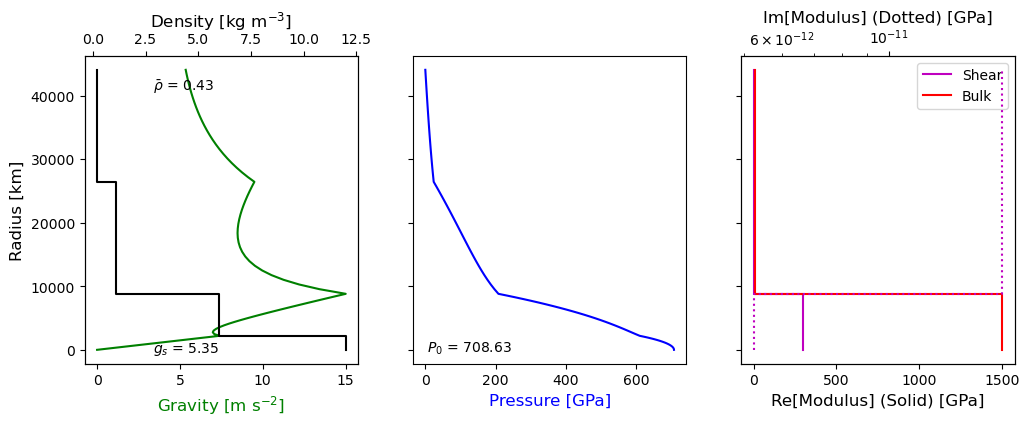

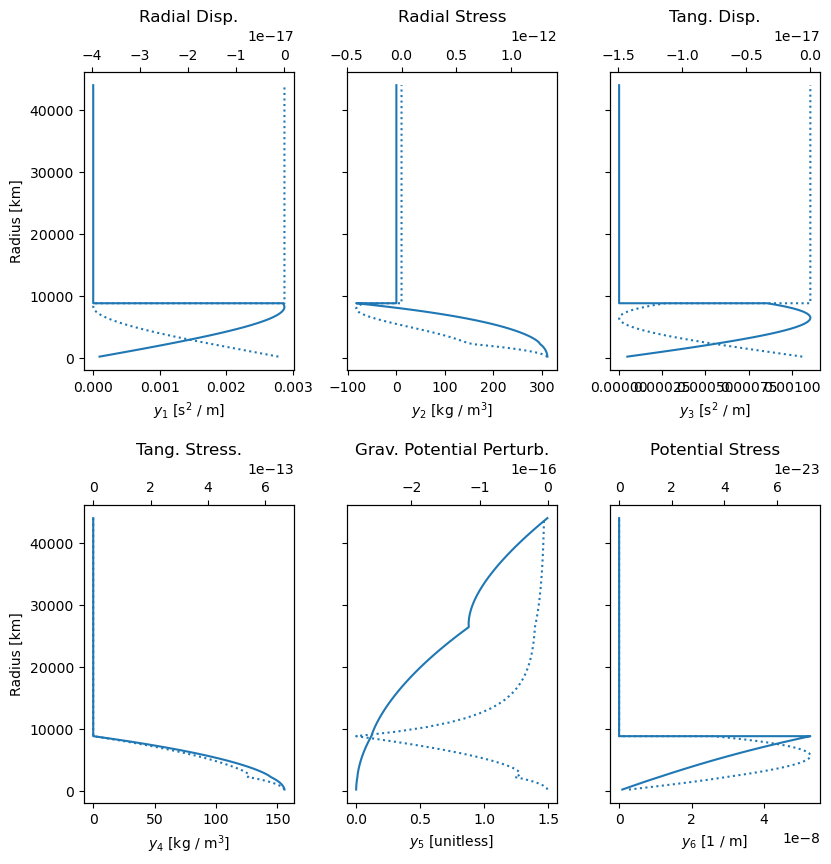

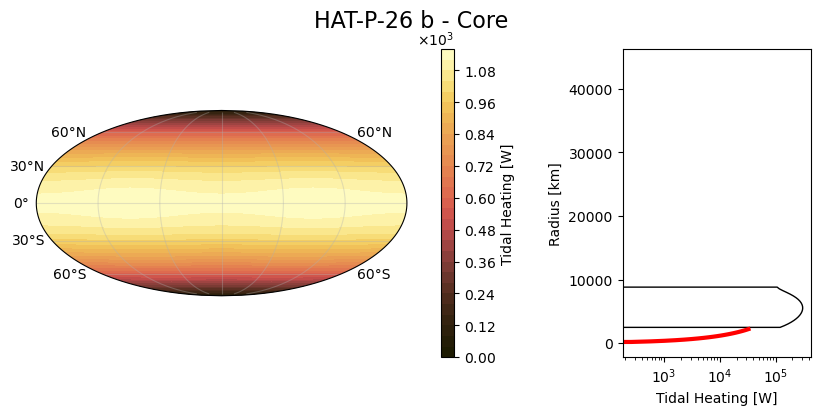

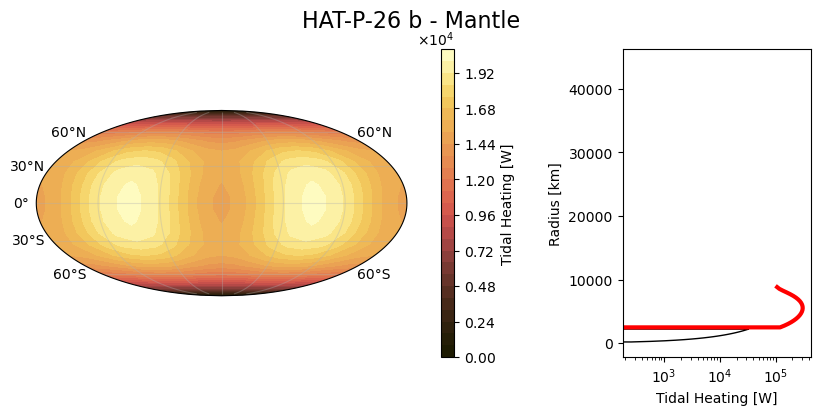

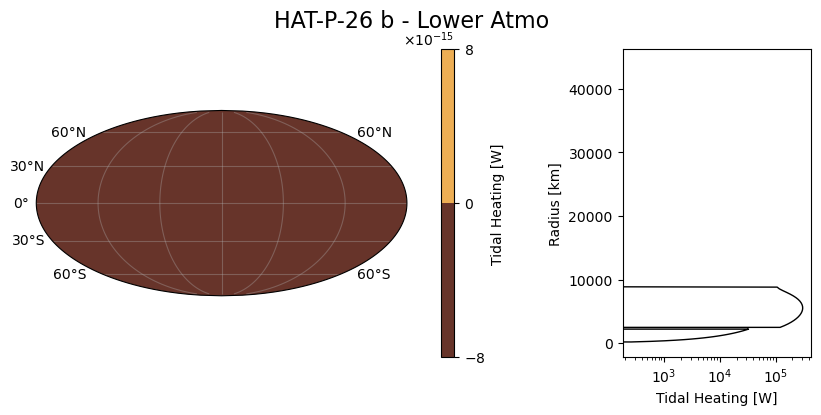

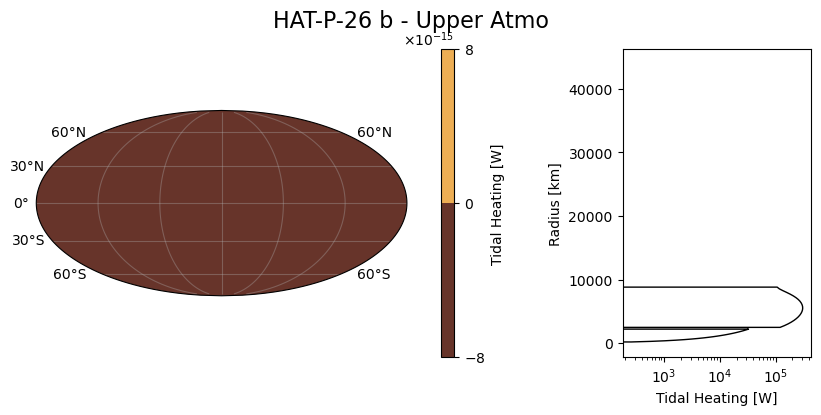

In [9]:
Hat_P_26b_sim_1.plot()